In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [ ]:
%pip install kagglehub

In [2]:
sns.set_style("whitegrid")
sns.set_context("notebook")

In [3]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/online-retail-dataset")

print("Path to dataset files:", path)

c:\Users\sable\OneDrive\Desktop\Visualization\.myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\sable\.cache\kagglehub\datasets\lakshmi25npathi\online-retail-dataset\versions\1


In [4]:
import os
print(os.listdir(path))

['online_retail_II.xlsx']


In [5]:
file = r"C:\Users\sable\.cache\kagglehub\datasets\lakshmi25npathi\online-retail-dataset\versions\1\online_retail_II.xlsx"

In [6]:
import pandas as pd

In [10]:
%pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
df_2009 = pd.read_excel(file, sheet_name = 'Year 2009-2010')
df_2010 = pd.read_excel(file, sheet_name = 'Year 2010-2011')
print(df_2009.head(2))

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  


In [12]:
print(df_2010.head(2))


  Invoice StockCode                         Description  Quantity  \
0  536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                 WHITE METAL LANTERN         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  


In [13]:
df_2009.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [14]:
df_2010.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [10]:
df = pd.concat([df_2009, df_2010], ignore_index = True)


In [11]:
df.shape

(1067371, 8)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [13]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [14]:
df.drop_duplicates(inplace = True)

In [15]:
df = df.dropna(subset=['Customer ID'])

In [16]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [17]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [18]:
cols = ['Invoice', 'StockCode', 'Customer ID', 'Country']
df[cols] = df[cols].astype('category')

In [19]:
df['Description'] = df['Description'].astype('string')

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  category      
 1   StockCode    779495 non-null  category      
 2   Description  779495 non-null  string        
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[us]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  category      
 7   Country      779495 non-null  category      
dtypes: category(4), datetime64[us](1), float64(1), int64(1), string(1)
memory usage: 36.9 MB


In [21]:
df['totalprice'] = df['Quantity'] * df['Price']

In [38]:
df.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,totalprice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0


In [22]:
df.shape

(779495, 9)

In [23]:
df['Country'].value_counts().head(10).index

CategoricalIndex(['United Kingdom', 'Germany', 'EIRE', 'France', 'Netherlands',
                  'Spain', 'Belgium', 'Switzerland', 'Portugal', 'Australia'],
                 categories=['Australia', 'Austria', 'Bahrain', 'Belgium', ..., 'United Arab Emirates', 'United Kingdom', 'Unspecified', 'West Indies'], ordered=False, dtype='category', name='Country')

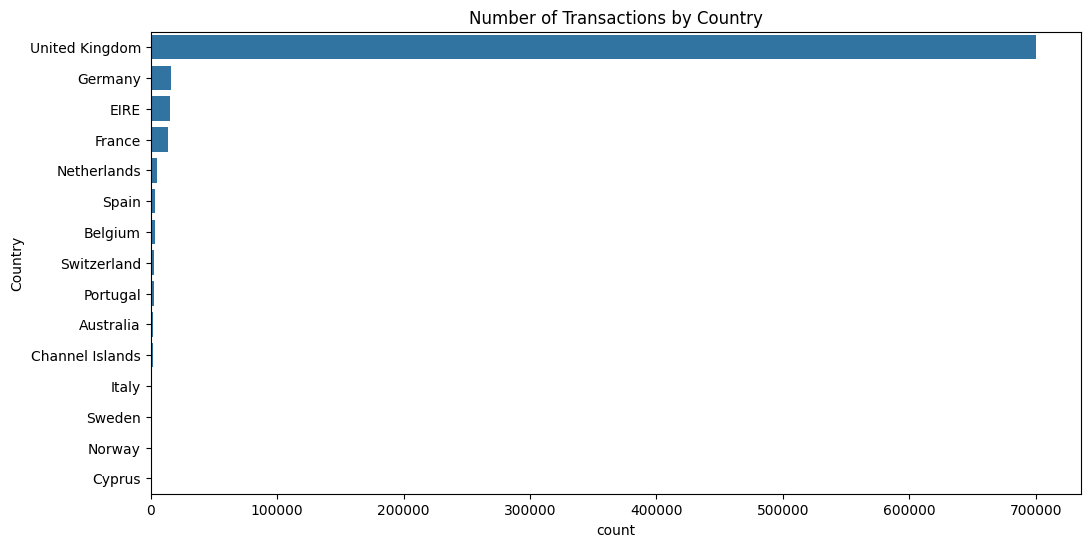

In [53]:
plt.figure(figsize = (12, 6))
sns.countplot(data = df, y='Country', order = df['Country'].value_counts().head(15).index)
plt.title("Number of Transactions by Country")
plt.show()

In [58]:
df['Description'].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    5016
REGENCY CAKESTAND 3 TIER              3337
ASSORTED COLOUR BIRD ORNAMENT         2692
JUMBO BAG RED RETROSPOT               2641
PARTY BUNTING                         2099
LUNCH BAG  BLACK SKULL.               2045
REX CASH+CARRY JUMBO SHOPPER          1950
LUNCH BAG SPACEBOY DESIGN             1890
STRAWBERRY CERAMIC TRINKET BOX        1859
HOME BUILDING BLOCK WORD              1852
Name: count, dtype: Int64

In [65]:
top = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64

C:\Users\sable\AppData\Local\Temp\ipykernel_1380\60899025.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top.values, y = top.index, palette = 'Set2')


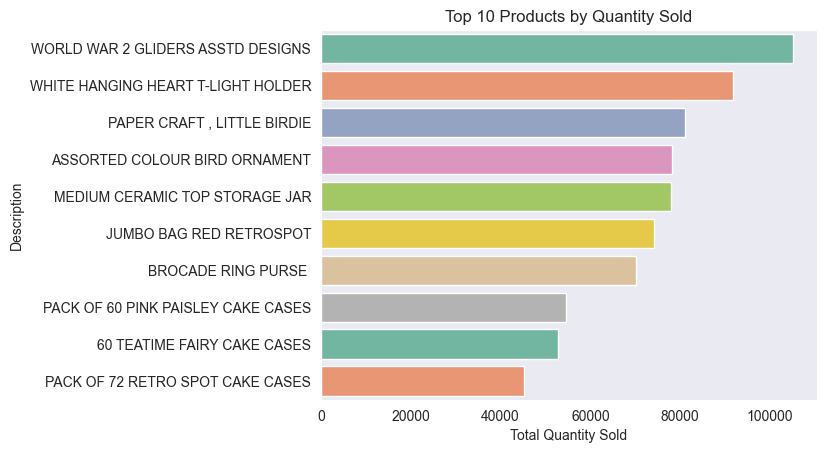

In [71]:
sns.set_style('dark')
sns.barplot(x = top.values, y = top.index, palette = 'Set2')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.show()

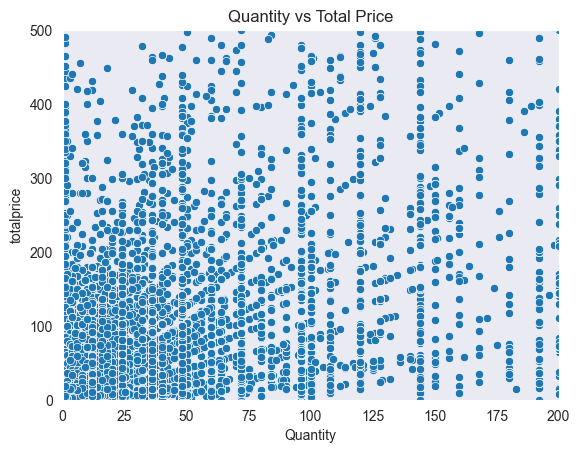

In [75]:
sns.scatterplot(data = df, x = 'Quantity', y = 'totalprice')
plt.title("Quantity vs Total Price")
plt.xlim(0, 200) 
plt.ylim(0, 500)
plt.show()

In [81]:
year1 = df['InvoiceDate'].dt.year
year1.unique()

array([2009, 2010, 2011], dtype=int32)

In [84]:
df['totalprice'].unique()

array([ 83.4 ,  81.  , 100.8 , ...,  25.08, 469.44,  66.36], shape=(3920,))

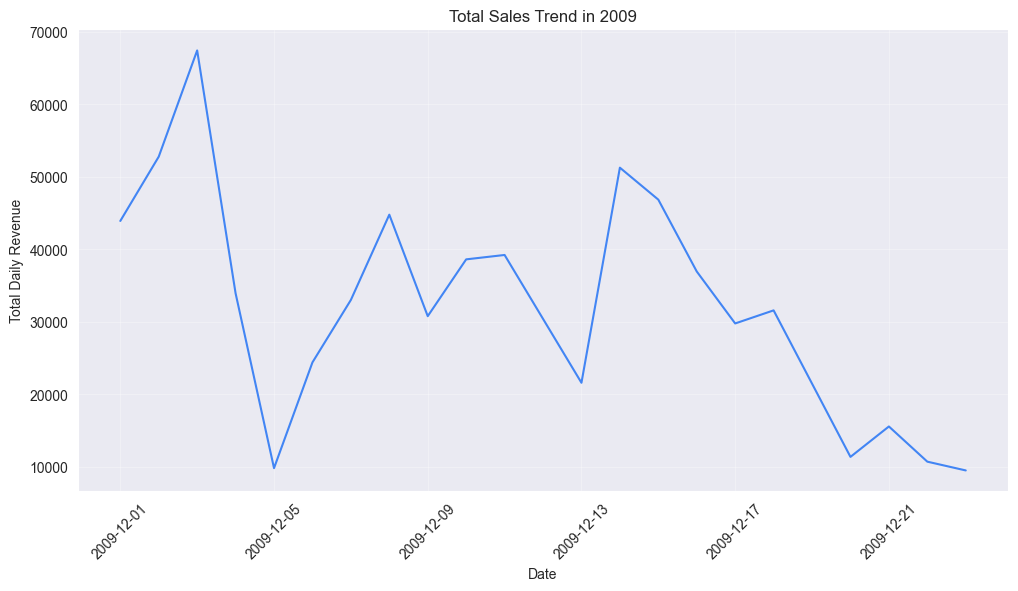

In [ ]:
df_2009 = df[df['InvoiceDate'].dt.year == 2009].copy()
daily_trend = df_2009.groupby(df_2009['InvoiceDate'].dt.date)['totalprice'].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_trend.index, y=daily_trend.values, color='#4285F4')
plt.title("Total Sales Trend in 2009")
plt.xlabel("Date")
plt.ylabel("Total Daily Revenue")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

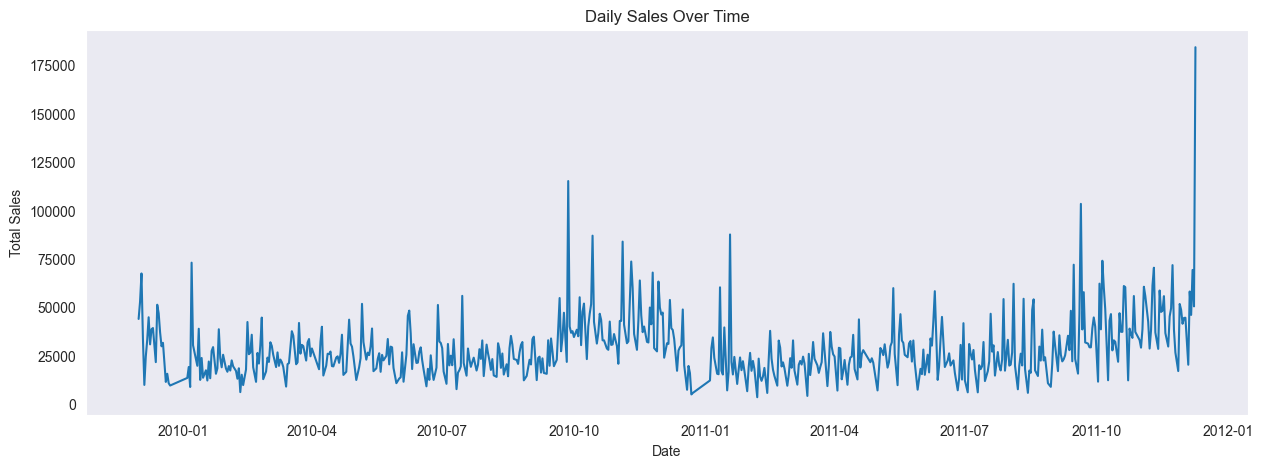

In [98]:
# Daily sales
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['totalprice'].sum()
plt.figure(figsize=(15,5))
daily_sales.plot()
plt.title("Daily Sales Over Time")
plt.ylabel("Total Sales")
plt.xlabel("Date")
plt.show()


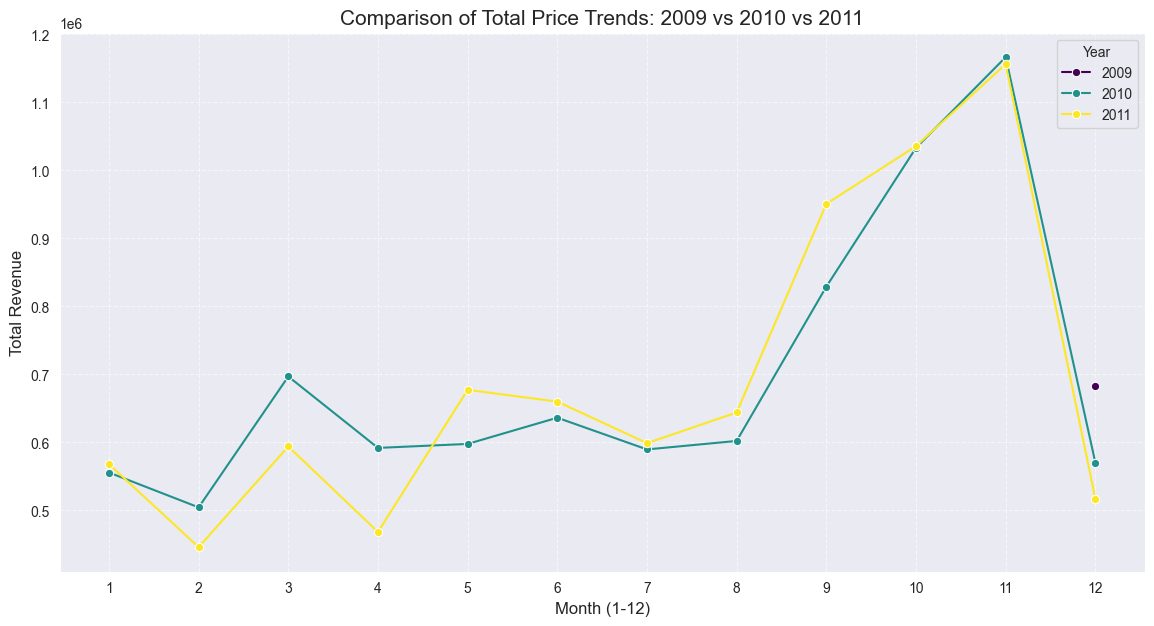

In [111]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

df_combined = df[df['Year'].isin([2009, 2010, 2011])]

monthly_revenue = df_combined.groupby(['Year', 'Month'])['totalprice'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_revenue, x='Month', y='totalprice', hue='Year', marker='o', palette='viridis')

plt.title("Comparison of Total Price Trends: 2009 vs 2010 vs 2011", fontsize=15)
plt.xlabel("Month (1-12)", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(range(1, 13))  
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Year')
plt.show()


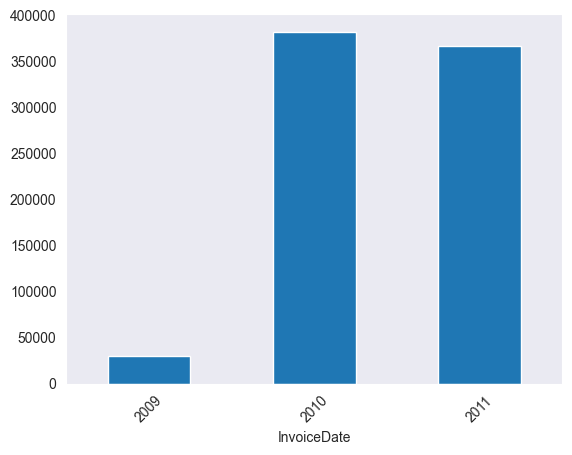

In [112]:
df.InvoiceDate.dt.year.value_counts(sort=False).plot(kind='bar', rot=45);

** Cohort Analysis **

In [57]:
print(f'oldest date: {df.InvoiceDate.min()}')
print(f'newest date: {df.InvoiceDate.max()}')

oldest date: 2009-12-01 07:45:00
newest date: 2011-12-09 12:50:00


In [58]:
# create cohort 
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = (
    df.groupby('Customer ID')['InvoiceMonth']
      .transform('min')
)


In [59]:
def cohort_index(df):
    year_diff = df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year
    month_diff = df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month
    return year_diff * 12 + month_diff + 1

df['CohortIndex'] = cohort_index(df)


In [60]:
# retention matrix - customer count per cohort
cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
      .nunique()
      .reset_index()
)
cohort_data.head(2)

,CohortMonth,CohortIndex,Customer ID
0,2009-12,1,955
1,2009-12,2,337


In [31]:
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns = 'CohortIndex', values='Customer ID')
cohort_pivot

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,376.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis = 0)

In [136]:
retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.352880,0.334031,0.425131,0.380105,0.359162,0.376963,0.342408,0.336126,0.362304,...,0.302618,0.262827,0.302618,0.282723,0.259686,0.255497,0.315183,0.304712,0.407330,0.196859
2010-01,1.0,0.206266,0.310705,0.305483,0.263708,0.300261,0.258486,0.229765,0.279373,0.318538,...,0.151436,0.234987,0.198433,0.185379,0.195822,0.242820,0.193211,0.245431,0.057441,NaN
2010-02,1.0,0.236702,0.223404,0.289894,0.244681,0.199468,0.191489,0.284574,0.252660,0.273936,...,0.199468,0.159574,0.162234,0.143617,0.228723,0.228723,0.162234,0.058511,NaN,NaN
2010-03,1.0,0.189616,0.230248,0.241535,0.232506,0.203160,0.246050,0.302483,0.275395,0.108352,...,0.169300,0.173815,0.155756,0.176072,0.200903,0.212190,0.079007,NaN,NaN,NaN
2010-04,1.0,0.193878,0.193878,0.163265,0.183673,0.224490,0.275510,0.261905,0.105442,0.108844,...,0.156463,0.139456,0.149660,0.180272,0.224490,0.057823,NaN,NaN,NaN,NaN
2010-05,1.0,0.157480,0.169291,0.173228,0.177165,0.255906,0.212598,0.125984,0.059055,0.082677,...,0.125984,0.137795,0.165354,0.153543,0.047244,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174074,0.188889,0.203704,0.229630,0.285185,0.125926,0.088889,0.081481,0.118519,...,0.122222,0.133333,0.203704,0.051852,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.155914,0.182796,0.295699,0.290323,0.139785,0.112903,0.145161,0.145161,0.112903,...,0.172043,0.236559,0.080645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.203704,0.296296,0.320988,0.172840,0.117284,0.098765,0.123457,0.135802,0.129630,...,0.197531,0.067901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


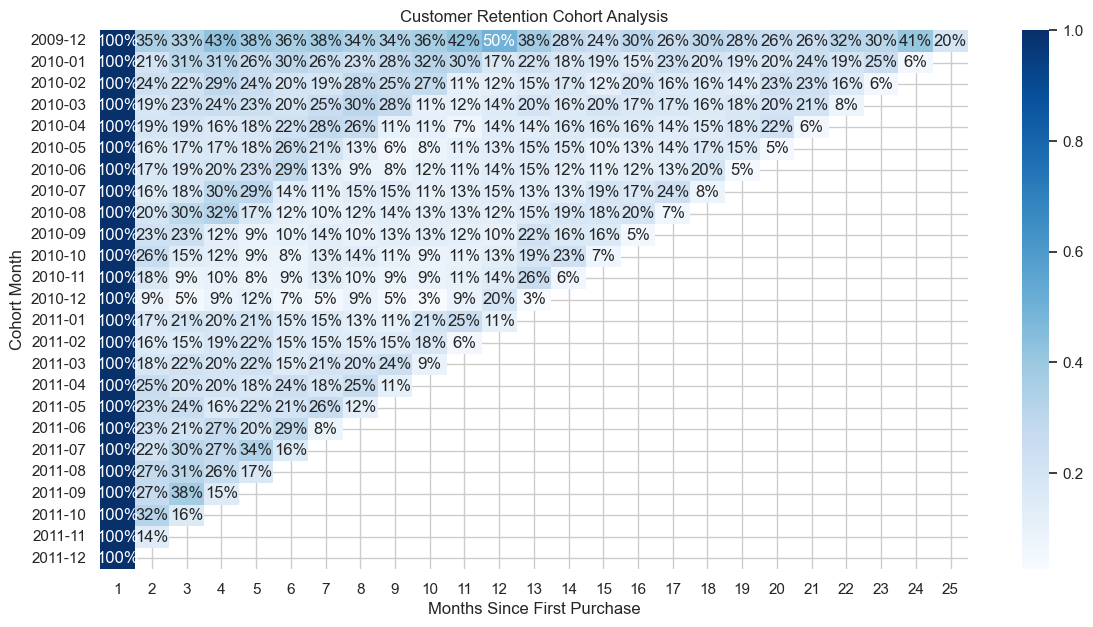

In [33]:
plt.figure(figsize=(14,7))
sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)
plt.title("Customer Retention Cohort Analysis")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")
plt.show()


RFM Analysis - (Recency, Frequency, Monetary)

Behavior-based customer segmentation technique used to categorize customers into groups based on their past purchasing patterns to predict future behavior and personalize marketing.

Cohort Analysis to find a month where retention dropped and then use RFM Analysis within that cohort to find exactly which high-value customers you lost.

Recency (R): How long it has been since a customer’s last purchase. Customers who bought recently are more likely to respond to new offers [1].
Frequency (F): How often a customer bought during a specific period. Frequent buyers demonstrate higher brand loyalty [2].
Monetary (M): How much total revenue the customer has generated. This identifies high-value spenders [2].


In [35]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days = 1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [38]:
rfm = (df.groupby('Customer ID').agg({'InvoiceDate': lambda x: (snapshot_date - x.max()).days, 'Invoice': 'nunique', 'totalprice':'sum'}). reset_index())
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head(3)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,12,77556.46
1,12347.0,1,8,4921.53
2,12348.0,74,5,2019.40


In [ ]:
# rfm scoring
rfm['R'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = rfm['R'].astype(str)+ rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Score'].head(2)


0    244
1    444
Name: RFM_Score, dtype: str

In [ ]:
def segment(row):
    # Convert values to string to ensure comparison works
    rfm_score = str(row['RFM_Score'])
    r = str(row['R'])
    f = str(row['F'])
    m = str(row['M'])

    if rfm_score in ['444', '443', '434']:
        return 'Champions'
    elif r == '4':
        return 'New Customers'
    elif f == '4':
        return 'Loyal Customers'
    elif m == '1':
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())


Segment
Others             2346
At Risk            1352
Champions           823
Loyal Customers     712
New Customers       648
Name: count, dtype: int64


In [52]:
rfm['Segment'].unique()

<StringArray>
['Loyal Customers', 'Champions', 'Others', 'At Risk', 'New Customers']
Length: 5, dtype: str

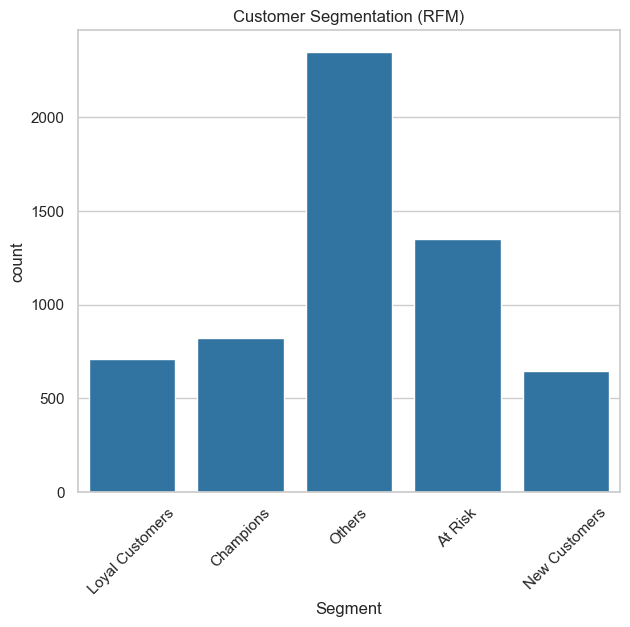

In [53]:
plt.figure(figsize = (7, 6))
sns.countplot(data= rfm, x = 'Segment')
plt.title("Customer Segmentation (RFM)")
plt.xticks(rotation=45)
plt.show()

CLV - Customer Lifetime Value

CLV=Average Order Value×Purchase Frequency×Customer Lifespan 💰 How much total money a customer is expected to bring to the business over their entire relationship.

Example:

Customer A buys once for ₹500 → leaves

Customer B buys ₹300 every month for 3 years → ₹10,800

Even though A spent more once, B is far more valuable.

1️⃣ Average Order Value (AOV)

How much money does a customer spend per order (on average)?

AOV
=
Total Money Spent /
Number of Orders

Example:

Total spent = ₹6,000

Orders = 10
👉 AOV = ₹600

💡 Tells you how “big” each purchase is.

2️⃣ Purchase Frequency

How often does the customer buy?

Example:

12 purchases in 1 year → high frequency

1 purchase in 1 year → low frequency

💡 Frequent buyers are more valuable than one-time buyers.

3️⃣ Customer Lifespan

How long (time) the customer stays with the company

Example:

First purchase: Jan 2020

Last purchase: Jan 2024
👉 Lifespan = 4 years

💡 Long-term customers = stable revenue.

Customer X:

Average Order Value = ₹500

Purchase Frequency = 8 orders/year

Customer Lifespan = 3 years

𝐶
𝐿
𝑉
=
500
×
8
×
3
=
₹
12
,
000
CLV=500×8×3=₹12,000

👉 This customer is worth ₹12,000 to the company.






In [55]:
avg_order_value = df.groupby('Customer ID')['totalprice'].mean()
purchase_freq = df.groupby('Customer ID')['Invoice'].nunique()
customer_lifespan = (df.groupby('Customer ID')['InvoiceDate'].max() - df.groupby('Customer ID')['InvoiceDate'].min()).dt.days / 365
clv = avg_order_value * purchase_freq * customer_lifespan
clv = clv.reset_index()
clv.columns = ['CustomerID', 'CLV']


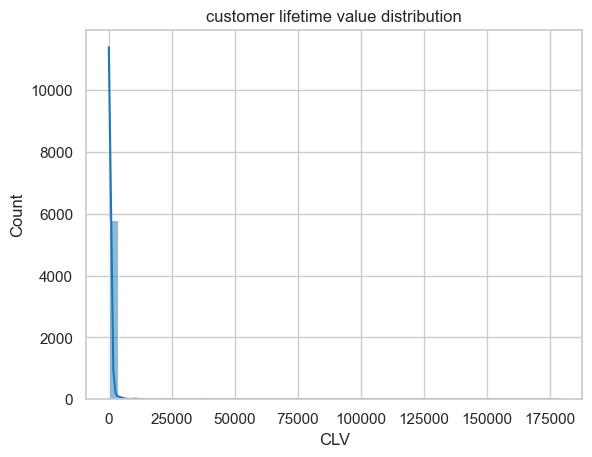

In [56]:
sns.histplot(clv['CLV'], bins = 50, kde = True)
plt.title("customer lifetime value distribution")
plt.show()